In [8]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
df=sns.load_dataset('iris')

In [10]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [12]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


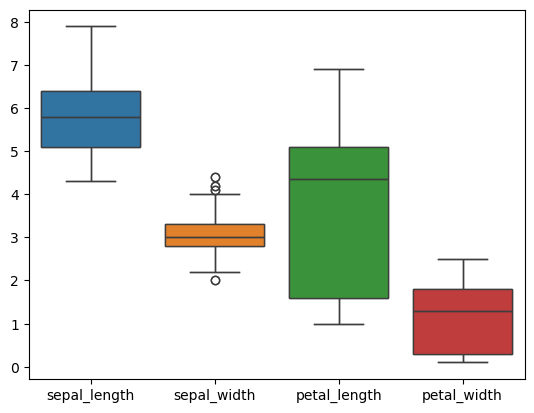

In [16]:
sns.boxplot(df)
plt.show()

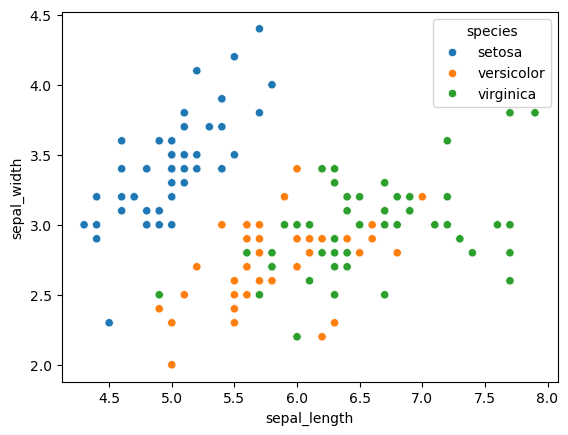

In [24]:
sns.scatterplot(x= df['sepal_length'],y= df['sepal_width'],hue='species',data=df)
plt.show()

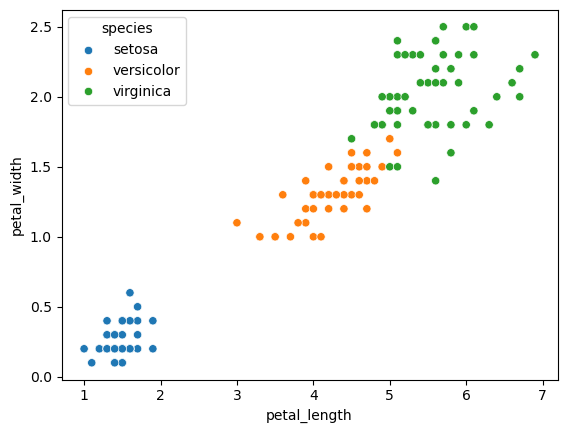

In [26]:
sns.scatterplot(x= df['petal_length'],y= df['petal_width'],hue='species',data=df)
plt.show()

In [28]:
df.duplicated().sum()

1

In [38]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [32]:
df = df.drop_duplicates()

In [34]:
df.duplicated().sum()

0

In [36]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

In [41]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [43]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [51]:
col = df.columns

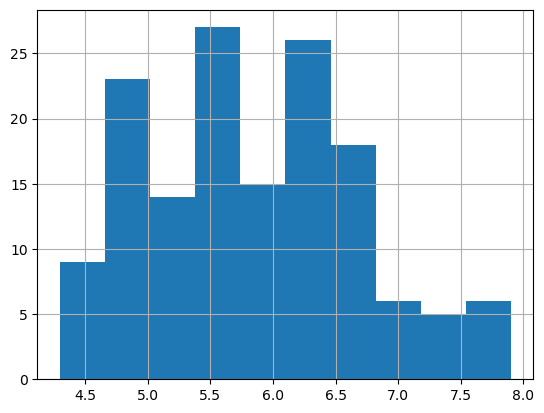

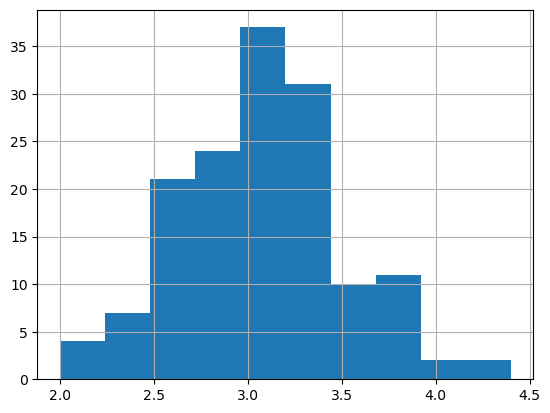

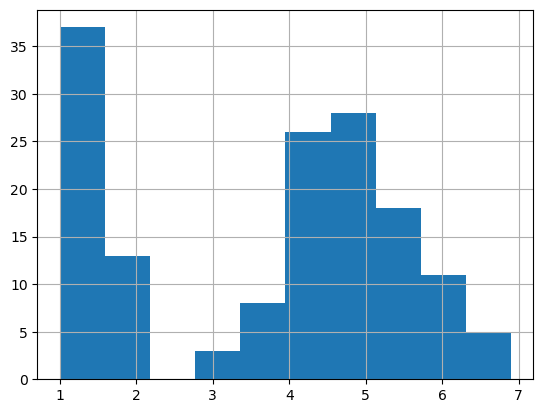

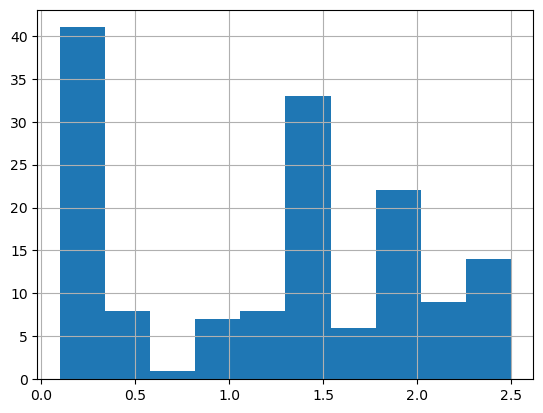

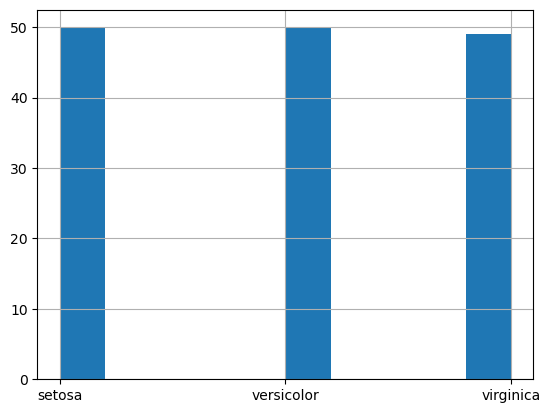

In [57]:
for i in col:
    df[i].hist()
    plt.show() 

Correlation Matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.118129      0.873738     0.820620
sepal_width      -0.118129     1.000000     -0.426028    -0.362894
petal_length      0.873738    -0.426028      1.000000     0.962772
petal_width       0.820620    -0.362894      0.962772     1.000000


<Figure size 800x600 with 0 Axes>

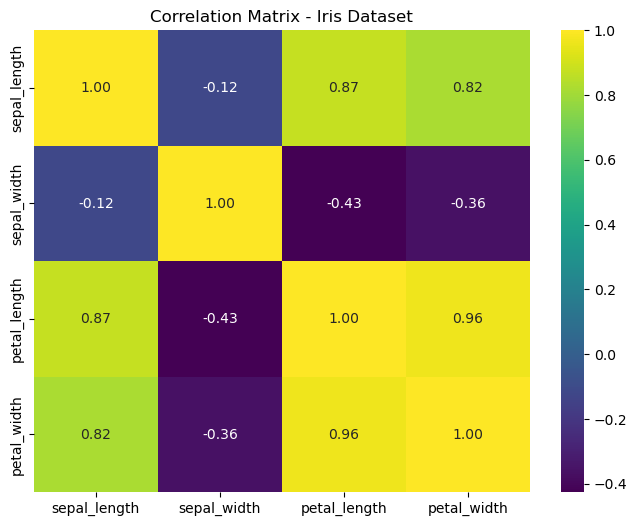

In [67]:
numeric_df = df.select_dtypes(include='number')  # drops 'species' or any non-numeric column
correlation_matrix = numeric_df.corr()

# Step 4: Print and plot
print("Correlation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title("Correlation Matrix - Iris Dataset")
plt.show()

In [69]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [75]:
df['species']=le.fit_transform(df['species'])

/var/folders/bt/b1fm956d4vs1y9q243w661jc0000gn/T/ipykernel_46986/3588174194.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['species']=le.fit_transform(df['species'])


In [77]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [79]:
from sklearn.model_selection import train_test_split
x = df.drop(columns='species')
y =df['species']
xt, xu , yt, yu = train_test_split(x , y , test_size=0.3 , random_state= 3)

In [85]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(xt,yt)

LogisticRegression()

In [89]:
y_pred_lr = lr.predict(xu)

In [93]:
from sklearn.metrics import r2_score
r2_score(y_pred_lr, yu)

0.9085365853658537

In [95]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(xt,yt)
y_pred_kn = lr.predict(xu)
r2_score(y_pred_kn, yu)

0.9085365853658537

In [99]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(xt,yt)
y_pred_dt = dt.predict(xu)
r2_score(y_pred_dt, yu)

0.9085365853658537